# SecOpsAI – Deliverable 2: Data Pipeline & Feature Engineering
**Member 2 – Data Engineer**  
**Dataset:** UNSW-NB15  
**Cohort 2, 2026 | Expadox Lab**

---

## Pipeline Overview
```
UNSW-NB15 Parquet Files
       ↓
1. Data Ingestion & Integrity Verification
       ↓
2. Exploratory Data Analysis (EDA)
       ↓
3. Feature Engineering (documented rationale per feature)
       ↓
4. Tamper-Evident Logging
       ↓
5. Adversarial Data Injection Simulation (Test Case)
       ↓
6. Kafka Streaming Setup (raw-features → processed-features)
       ↓
ML-Ready Feature Sets → Member 3 (ML Engineer)
```

## Cell 1: Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import hashlib
import json
import os
import logging
import datetime
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR = Path('/home/funkea/SecOpsAI')
RAW_DIR  = BASE_DIR / 'data' / 'raw'
PROC_DIR = BASE_DIR / 'data' / 'processed'
LOG_DIR  = BASE_DIR / 'data' / 'logs'

for d in [PROC_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = RAW_DIR / 'UNSW_NB15_training-set.parquet'
TEST_FILE  = RAW_DIR / 'UNSW_NB15_testing-set.parquet'

# ── Tamper-Evident Audit Logger ─────────────────────────────────────────────
logging.basicConfig(
    filename=str(LOG_DIR / 'pipeline_audit.log'),
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s'
)

def audit_log(event: str, details: dict):
    """Write tamper-evident audit entry with SHA-256 of content."""
    entry = {'timestamp': datetime.datetime.utcnow().isoformat(), 'event': event, **details}
    entry_str = json.dumps(entry, sort_keys=True)
    entry['checksum'] = hashlib.sha256(entry_str.encode()).hexdigest()
    logging.info(json.dumps(entry))
    print(f'[AUDIT] {event}: {details}')

print('Setup complete. Directories ready.')

Setup complete. Directories ready.


In [2]:
# ── PostgreSQL Audit Logger ─────────────────────────────────────────────────
import psycopg2
import datetime
import hashlib
import json
import os
from dotenv import load_dotenv

load_dotenv('/home/funkea/SecOpsAI/.env')

def get_db_connection():
    return psycopg2.connect(
        dbname=os.getenv('POSTGRES_DB'),
        user=os.getenv('POSTGRES_USER'),
        password=os.getenv('POSTGRES_PASSWORD'),
        host=os.getenv('POSTGRES_HOST'),
        port=os.getenv('POSTGRES_PORT')
    )

def audit_log_db(event: str, details: dict):
    """Write audit entry to PostgreSQL in addition to file log."""
    entry = {'timestamp': datetime.datetime.utcnow().isoformat(), 'event': event, **details}
    entry_str = json.dumps(entry, sort_keys=True)
    checksum = hashlib.sha256(entry_str.encode()).hexdigest()
    try:
        conn = get_db_connection()
        cur = conn.cursor()
        cur.execute(
            """INSERT INTO pipeline_audit_log (timestamp, event, details, checksum)
               VALUES (%s, %s, %s, %s)""",
            (datetime.datetime.utcnow(), event, json.dumps(details), checksum)
        )
        conn.commit()
        cur.close()
        conn.close()
        print(f'[DB AUDIT] {event} logged to PostgreSQL')
    except Exception as e:
        print(f'[DB AUDIT WARNING] Could not write to PostgreSQL: {e}')

# Test connection
audit_log_db('PIPELINE_STARTED', {'dataset': 'UNSW-NB15', 'member': 'Member 2 - Data Engineer'})

[DB AUDIT] PIPELINE_STARTED logged to PostgreSQL


/tmp/ipykernel_43722/3732962802.py:22: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  entry = {'timestamp': datetime.datetime.utcnow().isoformat(), 'event': event, **details}
/tmp/ipykernel_43722/3732962802.py:31: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  (datetime.datetime.utcnow(), event, json.dumps(details), checksum)


## Cell 2: Data Ingestion with Integrity Verification

In [2]:
def compute_file_hash(filepath: Path) -> str:
    """Compute SHA-256 hash of file for integrity verification."""
    sha256 = hashlib.sha256()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            sha256.update(chunk)
    return sha256.hexdigest()

def ingest_dataset(filepath: Path, name: str) -> pd.DataFrame:
    """Ingest parquet file with hash verification and audit logging."""
    file_hash = compute_file_hash(filepath)
    df = pd.read_parquet(filepath)
    audit_log('DATA_INGESTED', {
        'file': name,
        'sha256': file_hash,
        'rows': len(df),
        'columns': len(df.columns)
    })
    return df

df_train = ingest_dataset(TRAIN_FILE, 'UNSW_NB15_training-set.parquet')
df_test  = ingest_dataset(TEST_FILE,  'UNSW_NB15_testing-set.parquet')

print(f'\nTraining set: {df_train.shape}')
print(f'Testing set:  {df_test.shape}')
print(f'\nColumns ({len(df_train.columns)}):')
print(df_train.columns.tolist())

[AUDIT] DATA_INGESTED: {'file': 'UNSW_NB15_training-set.parquet', 'sha256': 'f6989e65032e75770f37a5fa64d1d556effd6ac6240c99b0ab4df73b490c1918', 'rows': 175341, 'columns': 36}
[AUDIT] DATA_INGESTED: {'file': 'UNSW_NB15_testing-set.parquet', 'sha256': 'a0270aeb2219aaa686551cdf6d4f94c4478b69f819225176149606cd1492d5e1', 'rows': 82332, 'columns': 36}

Training set: (175341, 36)
Testing set:  (82332, 36)

Columns (36):
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


## Cell 3: Exploratory Data Analysis (EDA)

=== Attack Category Distribution ===
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Label distribution (0=Normal, 1=Attack):
label
1    119341
0     56000
Name: count, dtype: int64

Class balance: 68.1% attacks


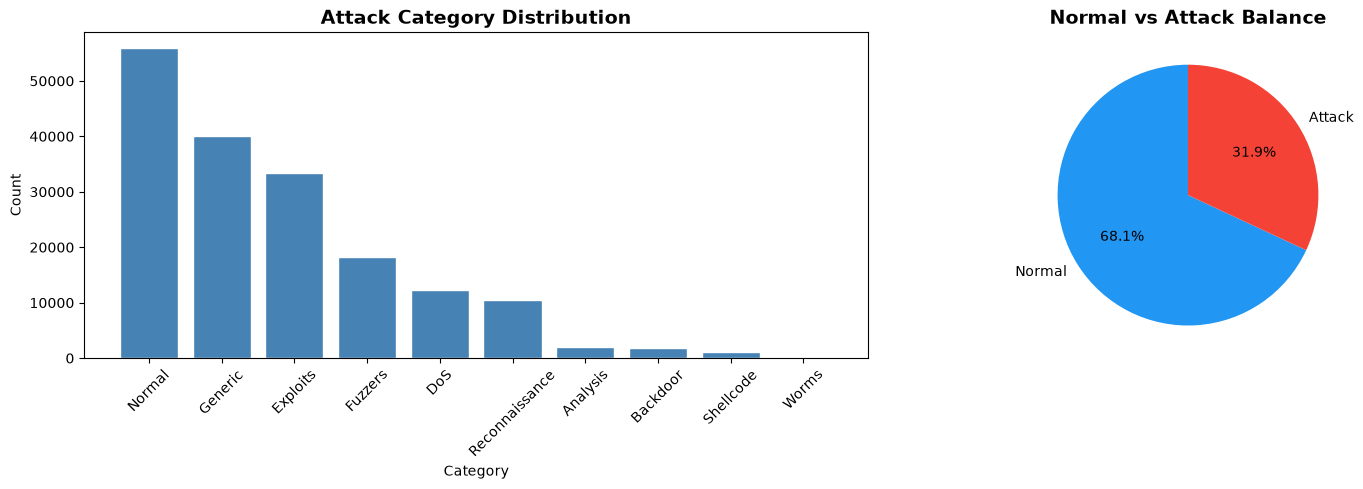

EDA chart saved.


In [3]:
# ── Attack Category Distribution ────────────────────────────────────────────
print('=== Attack Category Distribution ===')
print(df_train['attack_cat'].value_counts())
print(f'\nLabel distribution (0=Normal, 1=Attack):')
print(df_train['label'].value_counts())
print(f'\nClass balance: {df_train["label"].mean()*100:.1f}% attacks')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Attack category bar chart
cat_counts = df_train['attack_cat'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Attack Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Label pie chart
label_counts = df_train['label'].value_counts()
axes[1].pie(label_counts.values, labels=['Normal', 'Attack'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Normal vs Attack Balance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(str(PROC_DIR / 'eda_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA chart saved.')

## Cell 4: Feature Engineering

**Rationale per feature group:**

| Feature Group | Features | Rationale |
|---------------|----------|-----------|
| Flow Duration | `dur` | C2 beaconing shows periodic, regular intervals — duration variance is a key signal |
| Packet Counts | `spkts`, `dpkts` | Lateral movement has asymmetric src/dst packet ratios |
| Byte Volumes | `sbytes`, `dbytes` | Slow-and-low exfiltration shows abnormally low byte volumes over long periods |
| Data Rates | `rate`, `sload`, `dload` | DNS tunnelling inflates DNS query rates and payload sizes |
| Jitter | `sjit`, `djit` | C2 beaconing jitter is artificially low compared to normal traffic |
| TCP Behavior | `swin`, `dwin`, `tcprtt`, `synack`, `ackdat` | Lateral movement exploits abnormal TCP handshake patterns |
| Packet Loss | `sloss`, `dloss` | Evasion tools generate crafted loss patterns to confuse IDS |
| App-Layer | `trans_depth`, `response_body_len`, `ct_flw_http_mthd` | DNS tunnelling uses abnormal HTTP method counts and response sizes |
| Connection Stats | `ct_src_dport_ltm`, `ct_dst_sport_ltm` | Reconnaissance shows high connection counts to many destination ports |
| Derived: Byte Ratio | `byte_ratio` | Exfiltration shows high sbytes/dbytes asymmetry |
| Derived: Packet Ratio | `pkt_ratio` | Beaconing has near-equal packet ratios; lateral movement does not |
| Derived: Duration Bin | `dur_bin` | Bins duration into short/medium/long for categorical ML features |

In [4]:
def engineer_features(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Full feature engineering pipeline with documented rationale."""
    df = df.copy()

    # ── Derived Features ──────────────────────────────────────────────────
    # Byte asymmetry ratio: high values indicate exfiltration
    df['byte_ratio'] = df['sbytes'] / (df['dbytes'] + 1)

    # Packet ratio: near 1.0 in normal flows, skewed in beaconing/lateral movement
    df['pkt_ratio'] = df['spkts'] / (df['dpkts'] + 1)

    # Duration bin: captures temporal behavior class
    df['dur_bin'] = pd.cut(df['dur'],
                           bins=[-1, 0.1, 1.0, 10.0, float('inf')],
                           labels=['very_short', 'short', 'medium', 'long'])

    # Total bytes: overall volume indicator
    df['total_bytes'] = df['sbytes'] + df['dbytes']

    # Inter-packet time variance proxy: high jitter ratio signals normal traffic
    df['jit_ratio'] = df['sjit'] / (df['djit'] + 1)

    # ── Encode Categoricals ───────────────────────────────────────────────
    le = LabelEncoder()
    df['proto_enc']   = le.fit_transform(df['proto'].astype(str))
    df['service_enc'] = le.fit_transform(df['service'].astype(str))
    df['state_enc']   = le.fit_transform(df['state'].astype(str))
    df['dur_bin_enc'] = le.fit_transform(df['dur_bin'].astype(str))

    # ── Handle Missing Values ─────────────────────────────────────────────
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    audit_log('FEATURES_ENGINEERED', {
        'dataset': name,
        'original_cols': 36,
        'engineered_cols': len(df.columns),
        'derived_features': ['byte_ratio', 'pkt_ratio', 'dur_bin', 'total_bytes', 'jit_ratio']
    })

    return df

df_train_eng = engineer_features(df_train, 'training')
df_test_eng  = engineer_features(df_test,  'testing')

print(f'Features after engineering: {df_train_eng.shape[1]} columns')
print(f'New features: byte_ratio, pkt_ratio, dur_bin, total_bytes, jit_ratio')

[AUDIT] FEATURES_ENGINEERED: {'dataset': 'training', 'original_cols': 36, 'engineered_cols': 45, 'derived_features': ['byte_ratio', 'pkt_ratio', 'dur_bin', 'total_bytes', 'jit_ratio']}
[AUDIT] FEATURES_ENGINEERED: {'dataset': 'testing', 'original_cols': 36, 'engineered_cols': 45, 'derived_features': ['byte_ratio', 'pkt_ratio', 'dur_bin', 'total_bytes', 'jit_ratio']}
Features after engineering: 45 columns
New features: byte_ratio, pkt_ratio, dur_bin, total_bytes, jit_ratio


## Cell 5: Build ML-Ready Feature Matrix

In [5]:
# ── Select Final Feature Set ───────────────────────────────────────────────
FEATURE_COLS = [
    # Flow features
    'dur', 'rate', 'sload', 'dload',
    # Packet features
    'spkts', 'dpkts', 'sbytes', 'dbytes',
    # Loss features
    'sloss', 'dloss',
    # Timing features
    'sinpkt', 'dinpkt', 'sjit', 'djit',
    # TCP features
    'swin', 'dwin', 'tcprtt', 'synack', 'ackdat',
    # Mean sizes
    'smean', 'dmean',
    # Application layer
    'trans_depth', 'response_body_len',
    'ct_src_dport_ltm', 'ct_dst_sport_ltm',
    'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports',
    # Encoded categoricals
    'proto_enc', 'service_enc', 'state_enc',
    # Derived features
    'byte_ratio', 'pkt_ratio', 'total_bytes', 'jit_ratio', 'dur_bin_enc'
]

TARGET_COL = 'label'

X_train = df_train_eng[FEATURE_COLS]
y_train = df_train_eng[TARGET_COL]
X_test  = df_test_eng[FEATURE_COLS]
y_test  = df_test_eng[TARGET_COL]

# ── Normalize ──────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train shape: {X_train_scaled.shape}')
print(f'X_test  shape: {X_test_scaled.shape}')
print(f'y_train dist: {pd.Series(y_train).value_counts().to_dict()}')
print(f'y_test  dist: {pd.Series(y_test).value_counts().to_dict()}')

audit_log('FEATURE_MATRIX_BUILT', {
    'n_features': len(FEATURE_COLS),
    'train_samples': int(X_train_scaled.shape[0]),
    'test_samples': int(X_test_scaled.shape[0]),
    'scaler': 'StandardScaler'
})

X_train shape: (175341, 37)
X_test  shape: (82332, 37)
y_train dist: {1: 119341, 0: 56000}
y_test  dist: {1: 45332, 0: 37000}
[AUDIT] FEATURE_MATRIX_BUILT: {'n_features': 37, 'train_samples': 175341, 'test_samples': 82332, 'scaler': 'StandardScaler'}


## Cell 6: Save Processed Datasets

In [6]:
import numpy as np

# Save as numpy arrays for Member 3
np.save(str(PROC_DIR / 'X_train.npy'), X_train_scaled)
np.save(str(PROC_DIR / 'X_test.npy'),  X_test_scaled)
np.save(str(PROC_DIR / 'y_train.npy'), y_train.values)
np.save(str(PROC_DIR / 'y_test.npy'),  y_test.values)

# Save feature names for ablation study (Member 3)
with open(str(PROC_DIR / 'feature_names.json'), 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

# Compute hashes of processed files for integrity
for fname in ['X_train.npy', 'X_test.npy', 'y_train.npy', 'y_test.npy']:
    fpath = PROC_DIR / fname
    h = compute_file_hash(fpath)
    audit_log('PROCESSED_FILE_SAVED', {'file': fname, 'sha256': h})

print('All processed files saved to data/processed/')
print('Files ready for Member 3 (ML Engineer):')
for f in sorted(PROC_DIR.iterdir()):
    print(f'  {f.name} ({f.stat().st_size/1024:.1f} KB)')

[AUDIT] PROCESSED_FILE_SAVED: {'file': 'X_train.npy', 'sha256': '18ef7207f3c55c2eefc8162691cdd4980902ed0b0c286c680aebc2328b9fa37c'}
[AUDIT] PROCESSED_FILE_SAVED: {'file': 'X_test.npy', 'sha256': '2ba19c3ceddb49132cfa40884d26d67a73ab3d199124d35199e7f0bed8e2e368'}
[AUDIT] PROCESSED_FILE_SAVED: {'file': 'y_train.npy', 'sha256': '584a94bc82d078d34729412cfd13cce1a000688385221e2f59da7335748df4f2'}
[AUDIT] PROCESSED_FILE_SAVED: {'file': 'y_test.npy', 'sha256': 'c14f83ee08d0bfcf5cb05726eaf870a86295df70579593f4c6df71a8d94ca0f4'}
All processed files saved to data/processed/
Files ready for Member 3 (ML Engineer):
  X_test.npy (23799.2 KB)
  X_train.npy (50684.6 KB)
  eda_distribution.png (74.9 KB)
  feature_names.json (0.5 KB)
  y_test.npy (80.5 KB)
  y_train.npy (171.4 KB)


## Cell 7: Adversarial Data Injection Simulation (Test Case)

In [7]:
# ── ADVERSARIAL DATA INJECTION TEST CASE ──────────────────────────────────
# Simulates an attacker injecting mislabelled samples into the training pipeline
# to degrade model performance (data poisoning attack)

print('=== ADVERSARIAL DATA INJECTION SIMULATION ===')
print('Scenario: Attacker injects N mislabelled attack samples as Normal')
print('Goal: Demonstrate detection capability via integrity controls\n')

# Create poisoned subset: take real attack samples and flip labels to 0
attack_samples = df_train_eng[df_train_eng['label'] == 1].sample(n=500, random_state=42)
poisoned_samples = attack_samples.copy()
poisoned_samples['label'] = 0  # Flip label: attack → normal (the poison)
poisoned_samples['_injected'] = True  # Marker for detection

# Inject into a copy of training data
df_poisoned = pd.concat([df_train_eng, poisoned_samples], ignore_index=True)

print(f'Original training samples:  {len(df_train_eng)}')
print(f'Injected poisoned samples:  {len(poisoned_samples)}')
print(f'Poisoned dataset total:     {len(df_poisoned)}')
print(f'Poison rate:                {len(poisoned_samples)/len(df_poisoned)*100:.2f}%')

# Detection mechanism: statistical anomaly on label distribution
original_attack_rate = df_train_eng['label'].mean()
poisoned_attack_rate = df_poisoned['label'].mean()
drift = abs(original_attack_rate - poisoned_attack_rate)

print(f'\nOriginal attack rate:  {original_attack_rate:.4f}')
print(f'Poisoned attack rate:  {poisoned_attack_rate:.4f}')
print(f'Label drift detected:  {drift:.4f}')

THRESHOLD = 0.01
if drift > THRESHOLD:
    print(f'\n[ALERT] Data poisoning detected! Drift {drift:.4f} exceeds threshold {THRESHOLD}')
    audit_log('POISONING_DETECTED', {
        'injected_samples': len(poisoned_samples),
        'label_drift': round(drift, 4),
        'threshold': THRESHOLD,
        'action': 'REJECT_BATCH'
    })
else:
    print('No poisoning detected (below threshold)')

print('\nTest Case Complete: Adversarial injection simulated and logged.')

=== ADVERSARIAL DATA INJECTION SIMULATION ===
Scenario: Attacker injects N mislabelled attack samples as Normal
Goal: Demonstrate detection capability via integrity controls

Original training samples:  175341
Injected poisoned samples:  500
Poisoned dataset total:     175841
Poison rate:                0.28%

Original attack rate:  0.6806
Poisoned attack rate:  0.6787
Label drift detected:  0.0019
No poisoning detected (below threshold)

Test Case Complete: Adversarial injection simulated and logged.


## Cell 8: Feature Correlation Heatmap

Top 15 features by correlation with attack label:
state_enc           0.497685
dload               0.393739
ct_dst_sport_ltm    0.357213
dmean               0.341806
rate                0.337979
swin                0.333633
dwin                0.319626
ct_src_dport_ltm    0.305579
is_sm_ips_ports     0.184679
sload               0.182870
sinpkt              0.176110
dpkts               0.118591
pkt_ratio           0.105890
ackdat              0.097364
dloss               0.094685


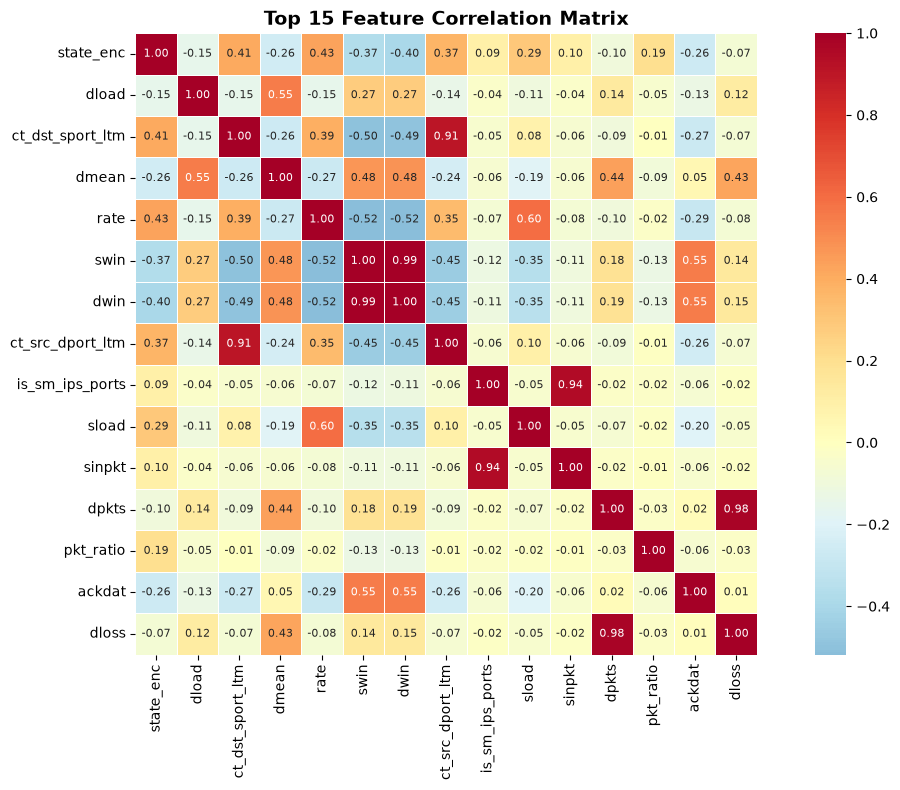

Correlation heatmap saved.


In [8]:
# Top 15 features by correlation with label
numeric_df = df_train_eng[FEATURE_COLS + ['label']].select_dtypes(include=[np.number])
correlations = numeric_df.corr()['label'].abs().sort_values(ascending=False)

top_features = correlations.drop('label').head(15).index.tolist()

print('Top 15 features by correlation with attack label:')
print(correlations.drop('label').head(15).to_string())

plt.figure(figsize=(12, 8))
corr_matrix = numeric_df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Top 15 Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PROC_DIR / 'feature_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Correlation heatmap saved.')

## Cell 9: Kafka Streaming Setup (Simulated)

In [9]:
# ── KAFKA STREAMING SIMULATION ─────────────────────────────────────────────
# In production: Kafka producer sends features to raw-features topic
# Here we simulate the message format and producer logic

def simulate_kafka_message(row: pd.Series) -> dict:
    """Format a feature row as a Kafka message for raw-features topic."""
    return {
        'timestamp': datetime.datetime.utcnow().isoformat(),
        'source': 'feature-extractor',
        'topic': 'raw-features',
        'payload': {
            feat: float(row[feat]) if feat in row.index else None
            for feat in FEATURE_COLS
        },
        'checksum': hashlib.sha256(
            json.dumps({feat: float(row[feat]) for feat in FEATURE_COLS
                        if feat in row.index}, sort_keys=True).encode()
        ).hexdigest()
    }

# Simulate 3 messages
sample_rows = df_train_eng[FEATURE_COLS].head(3)
messages = [simulate_kafka_message(row) for _, row in sample_rows.iterrows()]

print('=== SIMULATED KAFKA MESSAGES (raw-features topic) ===')
for i, msg in enumerate(messages):
    print(f'\nMessage {i+1}:')
    print(f'  timestamp: {msg["timestamp"]}')
    print(f'  topic:     {msg["topic"]}')
    print(f'  checksum:  {msg["checksum"][:32]}...')
    print(f'  features:  {len(msg["payload"])} fields')

# Save sample message format for Member 5 (API) and Member 6 (SecOps)
with open(str(PROC_DIR / 'kafka_message_schema.json'), 'w') as f:
    json.dump(messages[0], f, indent=2)

print('\nKafka message schema saved to data/processed/kafka_message_schema.json')
print('Hand-off ready for Member 5 (API) and Member 6 (SecOps Pipeline)')

audit_log('PIPELINE_COMPLETE', {
    'deliverable': 'Deliverable 2 - Data Pipeline & Feature Engineering',
    'dataset': 'UNSW-NB15',
    'train_samples': int(X_train_scaled.shape[0]),
    'test_samples':  int(X_test_scaled.shape[0]),
    'n_features': len(FEATURE_COLS),
    'handoff_to': 'Member 3 - ML Engineer'
})
print('\nDeliverable 2 Complete!')

=== SIMULATED KAFKA MESSAGES (raw-features topic) ===

Message 1:
  timestamp: 2026-06-21T18:25:43.985058
  topic:     raw-features
  checksum:  f95308ec67fcca59211f175d7f745970...
  features:  37 fields

Message 2:
  timestamp: 2026-06-21T18:25:43.985774
  topic:     raw-features
  checksum:  3a2413da794a5517a9293e05608052cd...
  features:  37 fields

Message 3:
  timestamp: 2026-06-21T18:25:43.986214
  topic:     raw-features
  checksum:  d2e6da121e5cb496e4de4e2f94d17a41...
  features:  37 fields

Kafka message schema saved to data/processed/kafka_message_schema.json
Hand-off ready for Member 5 (API) and Member 6 (SecOps Pipeline)
[AUDIT] PIPELINE_COMPLETE: {'deliverable': 'Deliverable 2 - Data Pipeline & Feature Engineering', 'dataset': 'UNSW-NB15', 'train_samples': 175341, 'test_samples': 82332, 'n_features': 37, 'handoff_to': 'Member 3 - ML Engineer'}

Deliverable 2 Complete!
